In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

rfm = pd.read_csv('../data/rfm.csv', index_col='CustomerID')
print(rfm.head())
print(rfm.shape)

X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


            Recency  Frequency  Monetary     LastPurchaseDate         Country
CustomerID                                                                   
12346.0         326          1  77183.60  2011-01-18 10:01:00  United Kingdom
12347.0           2          7   4310.00  2011-12-07 15:52:00         Iceland
12348.0          75          4   1797.24  2011-09-25 13:13:00         Finland
12349.0          19          1   1757.55  2011-11-21 09:51:00           Italy
12350.0         310          1    334.40  2011-02-02 16:01:00          Norway
(4262, 5)


array([[ 2.54748185, -0.42875293,  8.28480876],
       [-0.91334014,  0.34560048,  0.24549883],
       [-0.13358704, -0.04157623, -0.03170521],
       [-0.7317538 , -0.42875293, -0.03608376],
       [ 2.37657706, -0.42875293, -0.1930836 ]])

k=2, silhouette=0.895
k=3, silhouette=0.593
k=4, silhouette=0.616
k=5, silhouette=0.596
k=6, silhouette=0.596
k=7, silhouette=0.504
k=8, silhouette=0.477
k=9, silhouette=0.473
k=10, silhouette=0.429


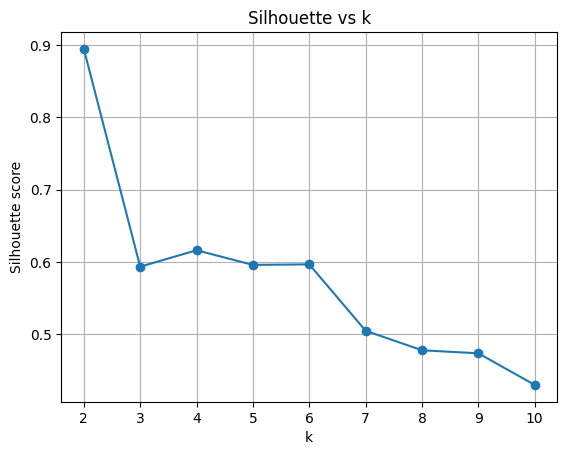

Best k: 2


In [2]:
sil_scores = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}, silhouette={sil:.3f}")

plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette vs k')
plt.grid(True)
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
print("Best k:", best_k)


In [3]:
best_k = int(best_k)  # ensure int
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

print(rfm['Segment'].value_counts())
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

# Save model and scaler
joblib.dump(kmeans, '../models/kmeans.joblib')
joblib.dump(scaler, '../models/scaler.joblib')

# Save segmented RFM
rfm.to_csv('../data/rfm_segmented.csv')


Segment
0    4236
1      26
Name: count, dtype: int64
         Recency  Frequency  Monetary
Segment                              
0          88.01       3.94   1570.16
1           6.04      66.50  85904.35


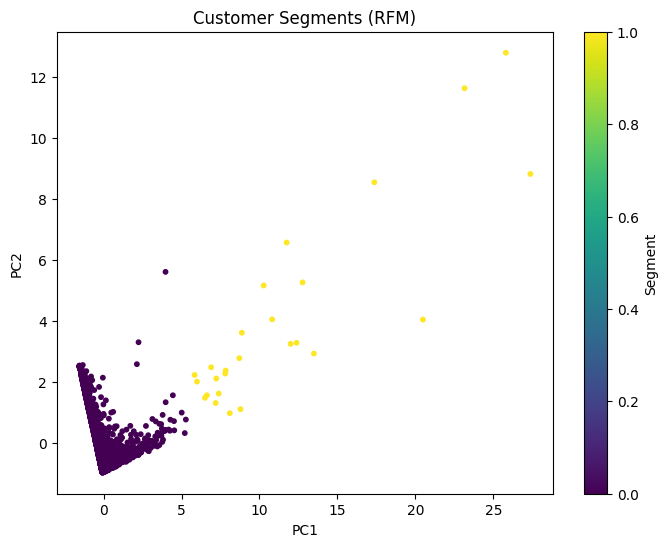

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=rfm['Segment'], cmap='viridis', s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (RFM)')
plt.colorbar(scatter, label='Segment')
plt.show()


In [5]:
import pandas as pd

rfm = pd.read_csv('../data/rfm.csv')
rfm.head()


,CustomerID,Recency,Frequency,Monetary,LastPurchaseDate,Country
0,12346.0,326,1,77183.60,2011-01-18 10:01:00,United Kingdom
1,12347.0,2,7,4310.00,2011-12-07 15:52:00,Iceland
2,12348.0,75,4,1797.24,2011-09-25 13:13:00,Finland
3,12349.0,19,1,1757.55,2011-11-21 09:51:00,Italy
4,12350.0,310,1,334.40,2011-02-02 16:01:00,Norway


In [6]:
import pandas as pd

rfm = pd.read_csv('../data/rfm_segmented.csv', index_col='CustomerID')
segment_stats = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2)
segment_counts = rfm['Segment'].value_counts().rename('Count')

segment_summary = segment_stats.join(segment_counts)
segment_summary


,Recency,Frequency,Monetary,Count
Segment,,,,
0,88.01,3.94,1570.16,4236
1,6.04,66.50,85904.35,26


In [7]:
def label_segment_from_rfm(r, f, m):
    if r <= 30 and f >= 10 and m >= 500:
        return "Loyal High-Value"
    elif r <= 30 and f < 10 and m < 500:
        return "New Customers"
    elif r > 90 and m >= 500:
        return "At-Risk VIP"
    elif r > 180:
        return "Lost / Inactive"
    else:
        return "Regular"


rfm['SegmentLabel'] = rfm.apply(lambda row: label_segment_from_rfm(
        row['Recency'], 
        row['Frequency'], 
        row['Monetary']
    ), axis=1)
rfm[['Recency','Frequency','Monetary','Segment','SegmentLabel']].head()


,Recency,Frequency,Monetary,Segment,SegmentLabel
CustomerID,,,,,
12346.0,326,1,77183.60,0,At-Risk VIP
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,0,Lost / Inactive


In [8]:
rfm.to_csv('../data/rfm_segmented_labeled.csv')


In [9]:
label_summary = rfm.groupby('SegmentLabel')[['Recency','Frequency','Monetary']].agg(['mean','count']).round(2)
label_summary


Recency       Frequency        Monetary      
                    mean count      mean count      mean count
SegmentLabel                                                  
At-Risk VIP       176.47   515      2.80   515   1548.16   515
Lost / Inactive   263.38   574      1.23   574    241.03   574
Loyal High-Value    9.51   346     20.26   346  12318.05   346
New Customers      16.31   369      1.65   369    276.88   369
Regular            49.46  2458      3.52  2458   1458.44  2458

In [10]:
import pandas as pd

tx = pd.read_csv('../data/transactions_clean.csv')

# Basket size = Monetary / Frequency we already have at RFM level; 
# but we can also calculate diversity (number of unique products)
cust_product_diversity = tx.groupby('CustomerID')['StockCode'].nunique().rename('ProductDiversity')

# Merge with RFM
rfm_ext = pd.read_csv('../data/rfm.csv', index_col='CustomerID')
rfm_ext = rfm_ext.join(cust_product_diversity, how='left').fillna(0)

# Average basket value
rfm_ext['AvgBasketValue'] = rfm_ext['Monetary'] / rfm_ext['Frequency']

rfm_ext.head()
rfm_ext.to_csv('../data/rfm_extended.csv')


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

rfm_ext = pd.read_csv('../data/rfm_extended.csv', index_col='CustomerID')
X_ext = rfm_ext[['Recency','Frequency','Monetary','ProductDiversity','AvgBasketValue']]

scaler_ext = StandardScaler()
X_ext_scaled = scaler_ext.fit_transform(X_ext)

results = []

for k in range(2, 9):
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_ext_scaled)
    km_sil = silhouette_score(X_ext_scaled, km_labels)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(X_ext_scaled)
    gmm_sil = silhouette_score(X_ext_scaled, gmm_labels)

    results.append({
        'k': k,
        'algo': 'KMeans',
        'silhouette': km_sil
    })
    results.append({
        'k': k,
        'algo': 'GMM',
        'silhouette': gmm_sil
    })

res_df = pd.DataFrame(results)
print(res_df)


    k    algo  silhouette
0   2  KMeans    0.917098
1   2     GMM    0.455089
2   3  KMeans    0.461629
3   3     GMM    0.387436
4   4  KMeans    0.462492
5   4     GMM    0.138129
6   5  KMeans    0.504984
7   5     GMM    0.064328
8   6  KMeans    0.508729
9   6     GMM   -0.002686
10  7  KMeans    0.497613
11  7     GMM   -0.002621
12  8  KMeans    0.424313
13  8     GMM   -0.007107


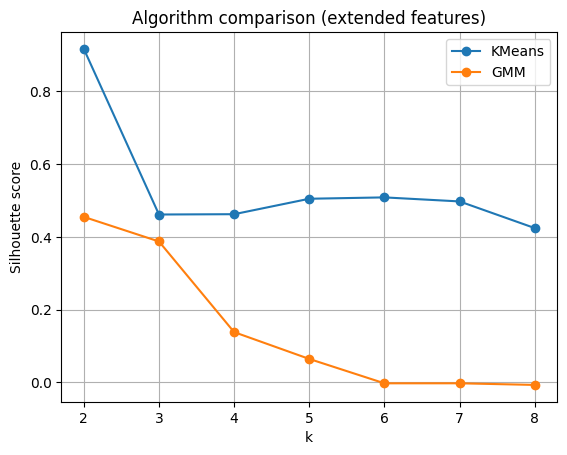

In [12]:
import matplotlib.pyplot as plt

for algo in ['KMeans','GMM']:
    sub = res_df[res_df['algo'] == algo]
    plt.plot(sub['k'], sub['silhouette'], marker='o', label=algo)

plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Algorithm comparison (extended features)')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
best_k_ext =  5
km_ext = KMeans(n_clusters=best_k_ext, random_state=42, n_init=10)
rfm_ext['SegmentExt'] = km_ext.fit_predict(X_ext_scaled)

joblib.dump(km_ext, '../models/kmeans_extended.joblib')
joblib.dump(scaler_ext, '../models/scaler_extended.joblib')

rfm_ext.to_csv('../data/rfm_extended_segmented.csv')
rfm_ext.groupby('SegmentExt')[['Recency','Frequency','Monetary','ProductDiversity','AvgBasketValue']].mean().round(2)


,Recency,Frequency,Monetary,ProductDiversity,AvgBasketValue
SegmentExt,,,,,
0,236.81,1.60,578.85,25.27,341.95
1,45.39,3.22,1122.38,47.32,362.01
2,163.50,1.50,122828.05,2.00,80709.92
3,7.00,79.81,105050.87,743.69,2097.90
4,17.95,13.38,6568.63,195.91,534.99


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

rfm_ext = pd.read_csv('../data/rfm_extended.csv', index_col='CustomerID')
X_ext = rfm_ext[['Recency','Frequency','Monetary','ProductDiversity','AvgBasketValue']]

scaler_ext = StandardScaler()
X_ext_scaled = scaler_ext.fit_transform(X_ext)

km_ext = KMeans(n_clusters=best_k_ext, random_state=42, n_init=10)
rfm_ext['SegmentExt'] = km_ext.fit_predict(X_ext_scaled)

joblib.dump(km_ext, '../models/kmeans_extended.joblib')
joblib.dump(scaler_ext, '../models/scaler_extended.joblib')

rfm_ext.to_csv('../data/rfm_extended_segmented.csv')
rfm_ext.groupby('SegmentExt')[['Recency','Frequency','Monetary','ProductDiversity','AvgBasketValue']].mean().round(2)


,Recency,Frequency,Monetary,ProductDiversity,AvgBasketValue
SegmentExt,,,,,
0,236.81,1.60,578.85,25.27,341.95
1,45.39,3.22,1122.38,47.32,362.01
2,163.50,1.50,122828.05,2.00,80709.92
3,7.00,79.81,105050.87,743.69,2097.90
4,17.95,13.38,6568.63,195.91,534.99
